In [6]:
import mysql.connector
from mysql.connector import Error
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# MySQL Connection
conn = mysql.connector.connect(
    host = "localhost",
    user = "root"      ,
    password = "parth004",
    database = "dummy"
)

# Employees Table
employees = pd.read_sql("SELECT * FROM employees", conn)

# Customers Table
customers = pd.read_sql("SELECT * FROM customers", conn)

# Offices Table
offices = pd.read_sql("SELECT * FROM offices", conn)

# Payments Table
payments = pd.read_sql("SELECT * FROM payments", conn)

# Orders Table
orders = pd.read_sql("SELECT * FROM orders", conn)

# Order Details Table
orderdetails = pd.read_sql("SELECT * FROM orderdetails", conn)

# Product Name Table
products = pd.read_sql("SELECT * FROM products", conn)

# Product Line Table
productlines = pd.read_sql("SELECT * FROM productlines", conn)

# Close connection
conn.close()

In [8]:
# Merge orders and customers DataFrames on customerNumber.
orders_customers = orders.merge(customers, on='customerNumber', how='left')
orders_customers

,orderNumber,orderDate,requiredDate,shippedDate,status,comments,customerNumber,customerName,contactLastName,contactFirstName,phone,addressLine1,addressLine2,city,state,postalCode,country,salesrepemployeenumber,creditLimit
0,10100,2003-01-06,2003-01-13,2003-01-10,Shipped,None,363,Online Diecast Creations Co.,Young,Dorothy,6035558647,2304 Long Airport Avenue,None,Nashua,NH,62005,USA,1216.0,114200.0
1,10101,2003-01-09,2003-01-18,2003-01-11,Shipped,Check on availability.,128,"Blauer See Auto, Co.",Keitel,Roland,+49 69 66 90 2555,Lyonerstr. 34,None,Frankfurt,None,60528,Germany,1504.0,59700.0
2,10102,2003-01-10,2003-01-18,2003-01-14,Shipped,None,181,Vitachrome Inc.,Frick,Michael,2125551500,2678 Kingston Rd.,Suite 101,NYC,NY,10022,USA,1286.0,76400.0
3,10103,2003-01-29,2003-02-07,2003-02-02,Shipped,None,121,Baane Mini Imports,Bergulfsen,Jonas,07-98 9555,Erling Skakkes gate 78,None,Stavern,None,4110,Norway,1504.0,81700.0
4,10104,2003-01-31,2003-02-09,2003-02-01,Shipped,None,141,Euro+ Shopping Channel,Freyre,Diego,(91) 555 94 44,"C/ Moralzarzal, 86",None,Madrid,None,28034,Spain,1370.0,227600.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
321,10421,2005-05-29,2005-06-06,None,In Process,Custom shipping instructions were sent to ware...,124,Mini Gifts Distributors Ltd.,Nelson,Susan,4155551450,5677 Strong St.,None,San Rafael,CA,97562,USA,1165.0,210500.0
322,10422,2005-05-30,2005-06-11,None,In Process,None,157,Diecast Classics Inc.,Leong,Kelvin,2155551555,7586 Pompton St.,None,Allentown,PA,70267,USA,1216.0,100600.0
323,10423,2005-05-30,2005-06-05,None,In Process,None,314,Petit Auto,Dewey,Catherine,(02) 5554 67,Rue Joseph-Bens 532,None,Bruxelles,None,B-1180,Belgium,1401.0,79900.0
324,10424,2005-05-31,2005-06-08,None,In Process,None,141,Euro+ Shopping Channel,Freyre,Diego,(91) 555 94 44,"C/ Moralzarzal, 86",None,Madrid,None,28034,Spain,1370.0,227600.0


In [9]:
# Merge orderdetails and products to get productName alongside each order line.
od_products = orderdetails.merge(products, on='productCode', how='left')
od_products

,orderNumber,productCode,quantityOrdered,priceEach,orderLineNumber,productName,productLine,productScale,productVendor,productDescription,quantityInStock,buyPrice,MSRP
0,10100,S18_1749,30,136.00,3,1917 Grand Touring Sedan,Vintage Cars,1:18,Welly Diecast Productions,This 1:18 scale replica of the 1917 Grand Tour...,2724,86.70,170.00
1,10100,S18_2248,50,55.09,2,1911 Ford Town Car,Vintage Cars,1:18,Motor City Art Classics,"Features opening hood, opening doors, opening ...",540,33.30,60.54
2,10100,S18_4409,22,75.46,4,1932 Alfa Romeo 8C2300 Spider Sport,Vintage Cars,1:18,Exoto Designs,This 1:18 scale precision die cast replica fea...,6553,43.26,92.03
3,10100,S24_3969,49,35.29,1,1936 Mercedes Benz 500k Roadster,Vintage Cars,1:24,Red Start Diecast,This model features grille-mounted chrome horn...,2081,21.75,41.03
4,10101,S18_2325,25,108.06,4,1932 Model A Ford J-Coupe,Vintage Cars,1:18,Autoart Studio Design,This model features grille-mounted chrome horn...,9354,58.48,127.13
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2991,10425,S24_2300,49,127.79,9,1962 Volkswagen Microbus,Trucks and Buses,1:24,Autoart Studio Design,This 1:18 scale die cast replica of the 1962 M...,2327,61.34,127.79
2992,10425,S24_2840,31,31.82,5,1958 Chevy Corvette Limited Edition,Classic Cars,1:24,Carousel DieCast Legends,The operating parts of this 1958 Chevy Corvett...,2542,15.91,35.36
2993,10425,S32_1268,41,83.79,11,1980’s GM Manhattan Express,Trucks and Buses,1:32,Motor City Art Classics,This 1980’s era new look Manhattan express is ...,5099,53.93,96.31
2994,10425,S32_2509,11,50.32,6,1954 Greyhound Scenicruiser,Trucks and Buses,1:32,Classic Metal Creations,"Model features bi-level seating, 50 windows, s...",2874,25.98,54.11


In [11]:
# Create a totalPrice column (quantityOrdered * priceEach) in the merged orderdetails+products table.
od_products['totalPrice'] = od_products['quantityOrdered'] * od_products['priceEach']
od_products

,orderNumber,productCode,quantityOrdered,priceEach,orderLineNumber,productName,productLine,productScale,productVendor,productDescription,quantityInStock,buyPrice,MSRP,totalPrice
0,10100,S18_1749,30,136.00,3,1917 Grand Touring Sedan,Vintage Cars,1:18,Welly Diecast Productions,This 1:18 scale replica of the 1917 Grand Tour...,2724,86.70,170.00,4080.00
1,10100,S18_2248,50,55.09,2,1911 Ford Town Car,Vintage Cars,1:18,Motor City Art Classics,"Features opening hood, opening doors, opening ...",540,33.30,60.54,2754.50
2,10100,S18_4409,22,75.46,4,1932 Alfa Romeo 8C2300 Spider Sport,Vintage Cars,1:18,Exoto Designs,This 1:18 scale precision die cast replica fea...,6553,43.26,92.03,1660.12
3,10100,S24_3969,49,35.29,1,1936 Mercedes Benz 500k Roadster,Vintage Cars,1:24,Red Start Diecast,This model features grille-mounted chrome horn...,2081,21.75,41.03,1729.21
4,10101,S18_2325,25,108.06,4,1932 Model A Ford J-Coupe,Vintage Cars,1:18,Autoart Studio Design,This model features grille-mounted chrome horn...,9354,58.48,127.13,2701.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2991,10425,S24_2300,49,127.79,9,1962 Volkswagen Microbus,Trucks and Buses,1:24,Autoart Studio Design,This 1:18 scale die cast replica of the 1962 M...,2327,61.34,127.79,6261.71
2992,10425,S24_2840,31,31.82,5,1958 Chevy Corvette Limited Edition,Classic Cars,1:24,Carousel DieCast Legends,The operating parts of this 1958 Chevy Corvett...,2542,15.91,35.36,986.42
2993,10425,S32_1268,41,83.79,11,1980’s GM Manhattan Express,Trucks and Buses,1:32,Motor City Art Classics,This 1980’s era new look Manhattan express is ...,5099,53.93,96.31,3435.39
2994,10425,S32_2509,11,50.32,6,1954 Greyhound Scenicruiser,Trucks and Buses,1:32,Classic Metal Creations,"Model features bi-level seating, 50 windows, s...",2874,25.98,54.11,553.52


In [12]:
# Group by customerNumber and find total revenue generated per customer.
revenue_df = od_products.merge(orders[['orderNumber', 'customerNumber']], on='orderNumber')
revenue_per_customer = revenue_df.groupby('customerNumber')['totalPrice'].sum().reset_index()
revenue_per_customer

,customerNumber,totalPrice
0,103,22314.36
1,112,80180.98
2,114,180585.07
3,119,158573.12
4,121,104224.79
...,...,...
93,486,77726.59
94,487,42570.37
95,489,29586.15
96,495,65541.74


In [13]:
# Find the top 10 customers by total revenue using groupby() and sort_values().
top10_customers = revenue_per_customer.sort_values('totalPrice', ascending=False).head(10)
top10_customers

,customerNumber,totalPrice
9,141,820689.54
5,124,591827.34
2,114,180585.07
14,151,177913.95
3,119,158573.12
13,148,156251.03
58,323,154622.08
8,131,149085.15
26,187,148410.09
83,450,143536.27


In [15]:
# Use pivot_table() to show total sales by productLine and orderYear.
orders['orderDate'] = pd.to_datetime(orders['orderDate'])
orders['orderYear'] = orders['orderDate'].dt.year

full_df = od_products.merge(orders[['orderNumber', 'customerNumber', 'orderYear']], on='orderNumber')
pivot_sales = full_df.pivot_table(values='totalPrice', index='productLine', 
                                    columns='orderYear', aggfunc='sum')
pivot_sales

orderYear,2003,2004,2005
productLine,,,
Classic Cars,1374832.22,1763136.73,715953.54
Motorcycles,348909.24,527243.84,245273.04
Planes,309784.20,471971.46,172881.88
Ships,222182.08,337326.10,104490.16
Trains,65822.05,96285.53,26425.34
Trucks and Buses,376657.12,465390.00,182066.45
Vintage Cars,619161.48,854551.85,323846.30


In [16]:
# Find the number of orders per status using value_counts().
status_counts = orders['status'].value_counts()
status_counts

status
Shipped       303
Cancelled       6
In Process      6
Resolved        4
On Hold         4
Disputed        3
Name: count, dtype: int64

In [17]:
# Handle missing values in addressLine2 (fill with 'N/A' instead of dropping).
customers['addressLine2'] = customers['addressLine2'].fillna('N/A')
customers

,customerNumber,customerName,contactLastName,contactFirstName,phone,addressLine1,addressLine2,city,state,postalCode,country,salesrepemployeenumber,creditLimit
0,103,bhopal,Schmitt,Carine,40.32.2555,"54, rue Royale",N/A,Nantes,None,44000,France,1370.0,22000.0
1,112,Signal Gift Stores,King,Jean,7025551838,8489 Strong St.,N/A,Las Vegas,NV,83030,USA,1166.0,71800.0
2,114,"Australian Collectors, Co.",Ferguson,Peter,03 9520 4555,636 St Kilda Road,Level 3,Melbourne,Victoria,3004,Australia,1611.0,117300.0
3,119,La Rochelle Gifts,Labrune,Janine,40.67.8555,"67, rue des Cinquante Otages",N/A,Nantes,None,44000,France,1370.0,118200.0
4,121,Baane Mini Imports,Bergulfsen,Jonas,07-98 9555,Erling Skakkes gate 78,N/A,Stavern,None,4110,Norway,1504.0,81700.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,486,Motor Mint Distributors Inc.,Salazar,Rosa,2155559857,11328 Douglas Av.,N/A,Philadelphia,PA,71270,USA,1323.0,72600.0
118,487,Signal Collectibles Ltd.,Taylor,Sue,4155554312,2793 Furth Circle,N/A,Brisbane,CA,94217,USA,1165.0,60300.0
119,489,"Double Decker Gift Stores, Ltd",Smith,Thomas,(171) 555-7555,120 Hanover Sq.,N/A,London,None,WA1 1DP,UK,1501.0,43300.0
120,495,Diecast Collectables,Franco,Valarie,6175552555,6251 Ingle Ln.,N/A,Boston,MA,51003,USA,1188.0,85100.0


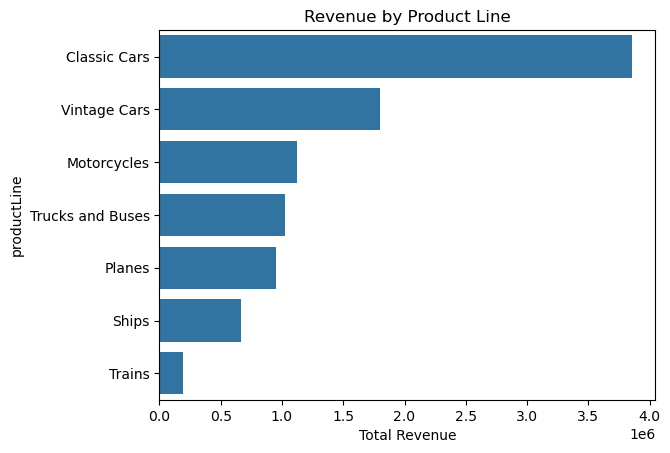

In [18]:
# Create a bar plot of total revenue by productLine using seaborn.
revenue_by_line = full_df.groupby('productLine')['totalPrice'].sum().sort_values(ascending=False)
sns.barplot(x=revenue_by_line.values, y=revenue_by_line.index)
plt.xlabel('Total Revenue')
plt.title('Revenue by Product Line')
plt.show()


In [19]:
# Find correlation between buyPrice and MSRP in the products DataFrame.
correlation = products['buyPrice'].corr(products['MSRP'])
print(correlation)


0.9191549811584666


In [21]:
# Use .apply() to create a custom profitMargin = (MSRP - buyPrice) / MSRP column.
products['profitMargin'] = products.apply(
    lambda row: (row['MSRP'] - row['buyPrice']) / row['MSRP'], axis=1
)*100
products

,productCode,productName,productLine,productScale,productVendor,productDescription,quantityInStock,buyPrice,MSRP,profitMargin
0,S10_1678,1969 Harley Davidson Ultimate Chopper,Motorcycles,1:10,Min Lin Diecast,"This replica features working kickstand, front...",7933,48.81,95.70,48.996865
1,S10_1949,1952 Alpine Renault 1300,Classic Cars,1:10,Classic Metal Creations,Turnable front wheels; steering function; deta...,7305,98.58,214.30,53.999067
2,S10_2016,1996 Moto Guzzi 1100i,Motorcycles,1:10,Highway 66 Mini Classics,"Official Moto Guzzi logos and insignias, saddl...",6625,68.99,118.94,41.995964
3,S10_4698,2003 Harley-Davidson Eagle Drag Bike,Motorcycles,1:10,Red Start Diecast,"Model features, official Harley Davidson logos...",5582,91.02,193.66,53.000103
4,S10_4757,1972 Alfa Romeo GTA,Classic Cars,1:10,Motor City Art Classics,Features include: Turnable front wheels; steer...,3252,85.68,136.00,37.000000
...,...,...,...,...,...,...,...,...,...,...
105,S700_3505,The Titanic,Ships,1:700,Carousel DieCast Legends,"Completed model measures 19 1/2 inches long, 9...",1956,51.09,100.17,48.996706
106,S700_3962,The Queen Mary,Ships,1:700,Welly Diecast Productions,Exact replica. Wood and Metal. Many extras inc...,5088,53.63,99.31,45.997382
107,S700_4002,American Airlines: MD-11S,Planes,1:700,Second Gear Diecast,Polished finish. Exact replia with official lo...,8820,36.27,74.03,51.006349
108,S72_1253,Boeing X-32A JSF,Planes,1:72,Motor City Art Classics,"10"" Wingspan with retractable landing gears.Co...",4857,32.77,49.66,34.011277


In [23]:
# Find the month with the highest number of orders (extract month from orderDate).
orders['orderMonth'] = orders['orderDate'].dt.month
month_counts = orders['orderMonth'].value_counts()
busiest_month = month_counts.idxmax()
busiest_month

np.int32(11)

In [24]:
# Detect and count duplicate rows in the customers DataFrame.
duplicate_count = customers.duplicated().sum()
duplicate_count

np.int64(0)

In [25]:
# Use groupby().agg() to get min, max, and mean MSRP per productLine.
msrp_stats = products.groupby('productLine')['MSRP'].agg(['min', 'max', 'mean'])
msrp_stats

,min,max,mean
productLine,,,
Classic Cars,35.36,214.30,118.021053
Motorcycles,40.23,193.66,97.178462
Planes,49.66,157.69,89.515833
Ships,54.60,122.89,86.563333
Trains,58.58,100.84,73.853333
Trucks and Buses,54.11,136.67,103.183636
Vintage Cars,33.19,170.00,87.095833


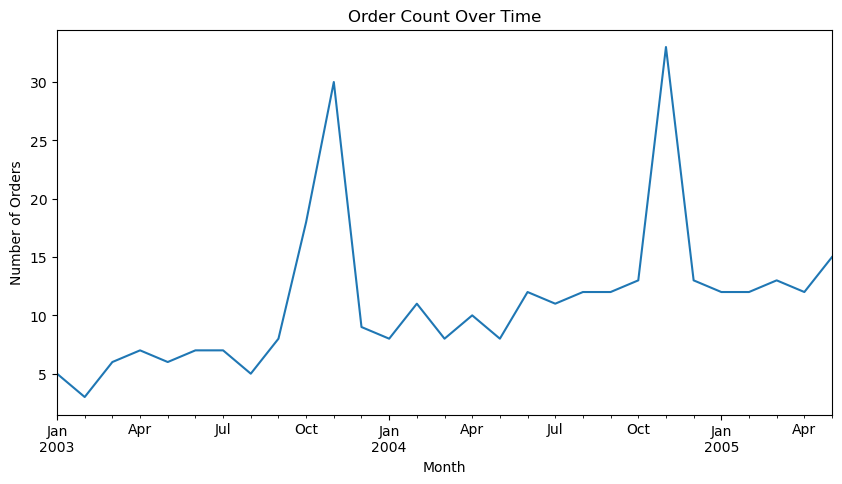

In [26]:
# Create a line plot showing total order count per month over time.
orders['orderYearMonth'] = orders['orderDate'].dt.to_period('M')
monthly_orders = orders.groupby('orderYearMonth').size()

monthly_orders.plot(kind='line', figsize=(10, 5))
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.title('Order Count Over Time')
plt.show()